In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# import data 
data = pd.read_csv("3) Sentiment dataset.csv", encoding='unicode_escape')

In [8]:
data.shape

(732, 15)

In [10]:

data["Timestamp"] = pd.to_datetime(data["Timestamp"])
data = data.sort_values("Timestamp")

In [11]:
data.set_index("Timestamp", inplace=True)

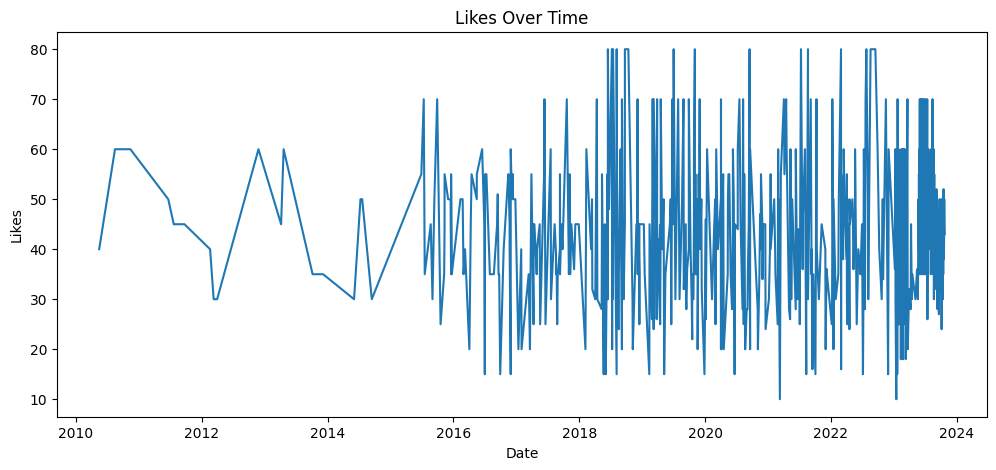

In [12]:

plt.figure(figsize=(12,5))
plt.plot(data.index, data["Likes"])
plt.title("Likes Over Time")
plt.xlabel("Date")
plt.ylabel("Likes")
plt.show()

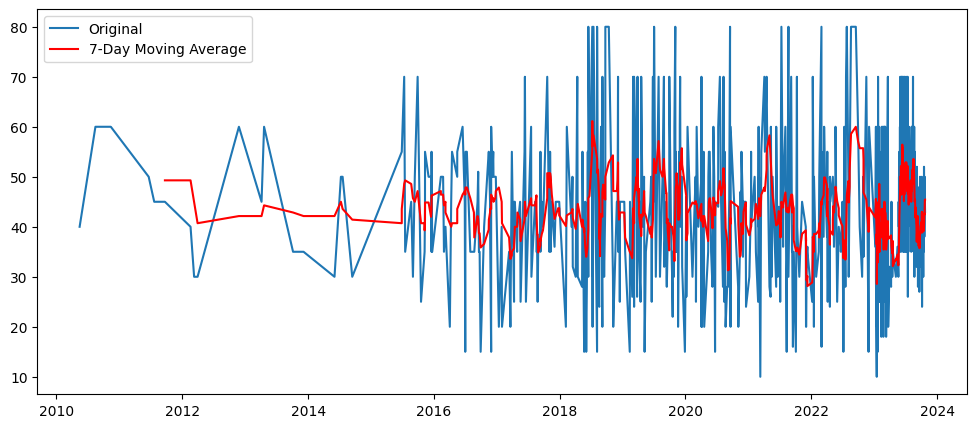

In [13]:
data["Moving_Avg"] = data["Likes"].rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(data.index, data["Likes"], label="Original")
plt.plot(data.index, data["Moving_Avg"], color="red", label="7-Day Moving Average")
plt.legend()
plt.show()

In [15]:
!pip install statsmodels


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 5.7 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.5 MB 7.1 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.5 MB 7.7 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.5 MB 7.5 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.5 MB 8.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 8.5 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   --------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [18]:
print(data.head())

                     Unnamed: 0.1  Unnamed: 0  \
Timestamp                                       
2010-05-15 15:30:00           110         112   
2010-08-15 10:00:00           125         127   
2010-11-12 20:20:00           152         154   
2011-06-20 14:45:00           112         114   
2011-07-22 18:30:00           153         155   

                                                                  Text  \
Timestamp                                                                
2010-05-15 15:30:00   Revisiting old memories, feeling a sense of e...   
2010-08-15 10:00:00   Contentment in the simplicity of a quiet Sund...   
2010-11-12 20:20:00   Contentment in the embrace of a loved one.   ...   
2011-06-20 14:45:00   Embracing the beauty of nature, a moment of c...   
2011-07-22 18:30:00   Serenity found in the beauty of a sunset by t...   

                           Sentiment               User     Platform  \
Timestamp                                                        

In [19]:
print(data.columns)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'User', 'Platform',
       'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day',
       'Hour', 'Moving_Avg'],
      dtype='object')


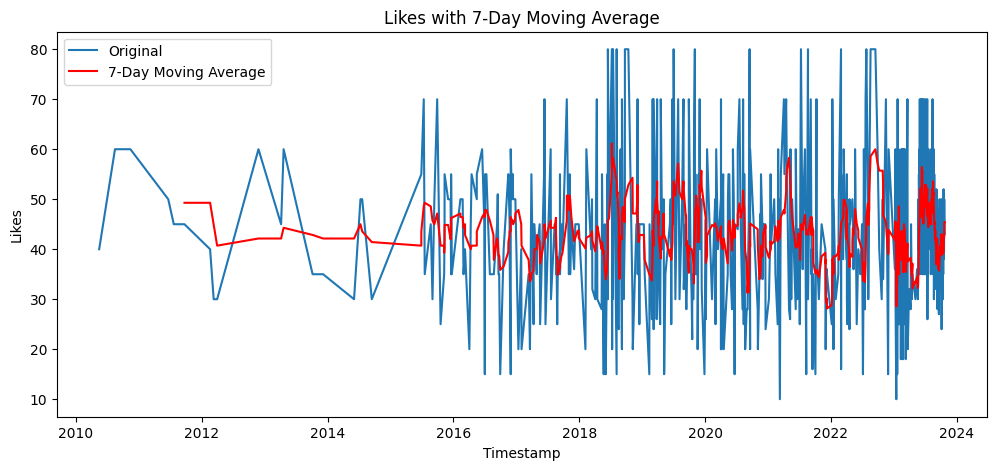

In [21]:


data["Moving_Avg"] = data["Likes"].rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(data.index, data["Likes"], label="Original")
plt.plot(data.index, data["Moving_Avg"], color="red", label="7-Day Moving Average")

plt.title("Likes with 7-Day Moving Average")
plt.xlabel("Timestamp")
plt.ylabel("Likes")
plt.legend()
plt.show()

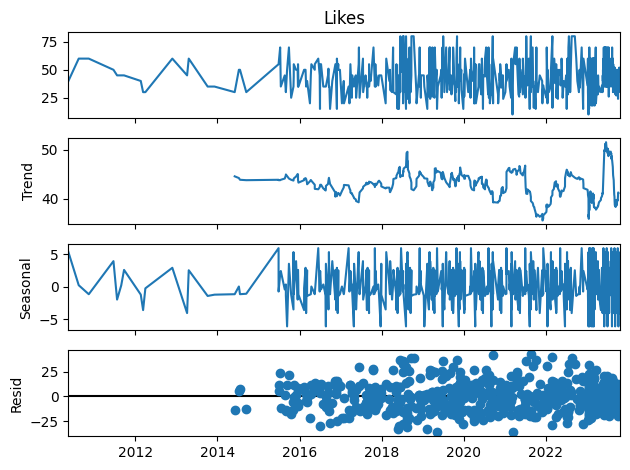

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    data["Likes"],
    model="additive",
    period=30
)

result.plot()
plt.show()

A time-series analysis was performed on the social media dataset using the Likes variable. The original time-series plot illustrated fluctuations in user engagement over time. A 7-day moving average was applied to smooth short-term variations and reveal the underlying trend. Seasonal decomposition further separated the data into trend, seasonal, and residual components, making it easier to understand long-term behavior, recurring patterns, and random fluctuations. Overall, the analysis provided valuable insights into temporal changes in user engagement.